In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
%matplotlib inline


In [2]:
data = load_diabetes()

In [ ]:
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [7]:
for keys in data.keys():
    print(keys)

data
target
frame
DESCR
feature_names
data_filename
target_filename
data_module


In [17]:
x = pd.DataFrame(data['data'],columns=data['feature_names'])

In [18]:
x

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [19]:
y=data['target']

In [20]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.23,random_state=42)

In [26]:
x_train.shape

(340, 10)

In [37]:
x_test.shape

(102, 10)

<Axes: >

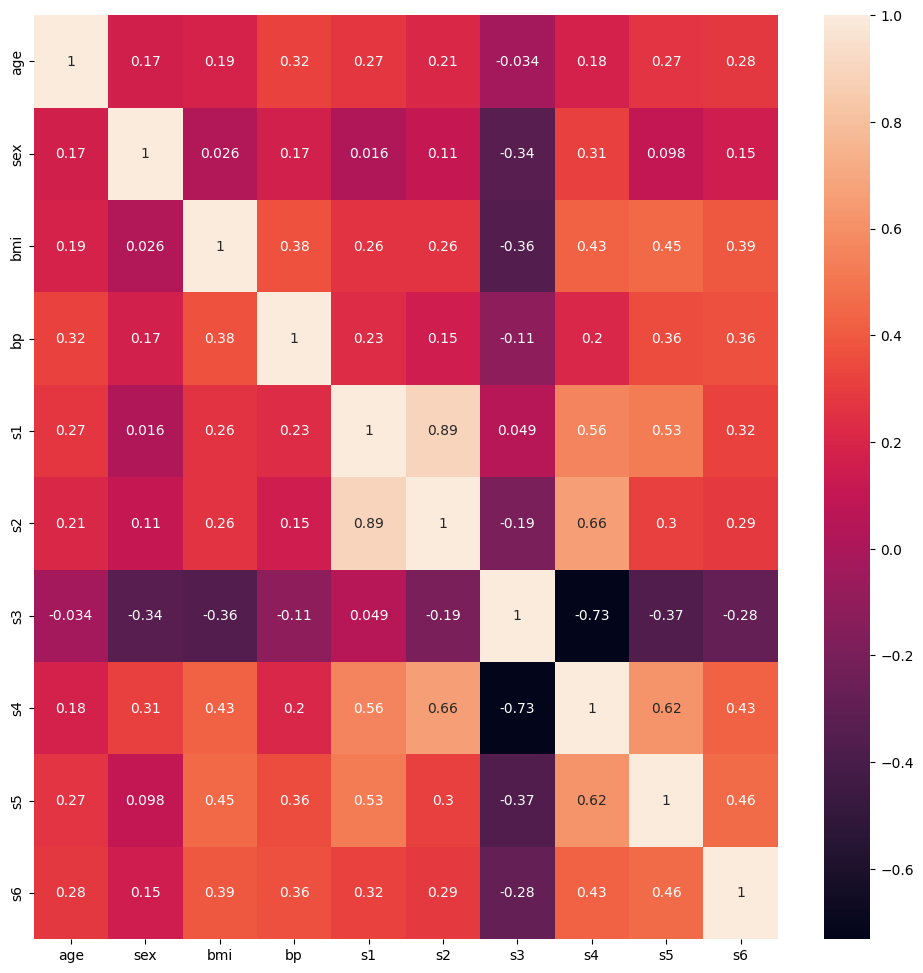

In [30]:
import seaborn as sns
plt.figure(figsize=(12,12))
sns.heatmap(x_train.corr(),annot=True)

In [31]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(x_train,y_train)

DecisionTreeRegressor()

In [40]:
from sklearn.metrics import r2_score,mean_squared_error
y_pred = model.predict(x_test)
print(r2_score(y_pred,y_test))
print(mean_squared_error(y_pred,y_test))
#very very bad accuracy
#find the accuracy for training data
y_pred_train = model.predict(x_train)
print("train R2:",r2_score(y_pred_train,y_train))
print("train MSE: ",mean_squared_error(y_pred_train,y_train))
#perfect accuracy on training data and wrost accuracy on test data

0.048679805779862084
5637.0392156862745
train R2: 1.0
train MSE:  0.0


In [41]:
# Hyperparameter tuning
param = {
    'criterion' : ['squared_error','friedman_mse','absolute_error'],
    'splitter' : ['best','random'],
    'max_depth': [1,2,3,4,5,10,15,20,25],
    'max_features' : ['auto','sqrt','log2']
}

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
grid = GridSearchCV(DecisionTreeRegressor(),param_grid=param,cv=5,scoring='r2')

In [48]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='r2')

In [49]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 3,
 'max_features': 'log2',
 'splitter': 'best'}

In [50]:
grid.best_score_

np.float64(0.305357462319526)

In [51]:
#let's try to visualise 
#create a new model with selected parameters by grid search cv
model = DecisionTreeRegressor(criterion='friedman_mse',max_depth=3,max_features='log2',splitter='best')

In [52]:
model.fit(x_train,y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      max_features='log2')

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error
y_pred = model.predict(x_test)
print(r2_score(y_pred,y_test))
print(mean_squared_error(y_pred,y_test))
#not good score but better than the first one without any parameters 
y_pred_train = model.predict(x_train)
print("train R2:",r2_score(y_pred_train,y_train))
print("train MSE: ",mean_squared_error(y_pred_train,y_train))
#no overfitting as the score is not perfect 1

-0.22879492889103026
2994.2447094544054
train R2: 0.01718632742844073
train MSE:  3009.0170387314206


[Text(0.5, 0.875, 'x[8] <= -0.0\nfriedman_mse = 6070.652\nsamples = 340\nvalue = 153.803'),
 Text(0.25, 0.625, 'x[2] <= 0.006\nfriedman_mse = 3609.649\nsamples = 174\nvalue = 113.92'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[5] <= 0.113\nfriedman_mse = 2360.013\nsamples = 136\nvalue = 98.846'),
 Text(0.0625, 0.125, 'friedman_mse = 2200.164\nsamples = 135\nvalue = 97.704'),
 Text(0.1875, 0.125, 'friedman_mse = 0.0\nsamples = 1\nvalue = 253.0'),
 Text(0.375, 0.375, 'x[5] <= 0.016\nfriedman_mse = 4358.325\nsamples = 38\nvalue = 167.868'),
 Text(0.3125, 0.125, 'friedman_mse = 4229.574\nsamples = 25\nvalue = 150.16'),
 Text(0.4375, 0.125, 'friedman_mse = 2843.148\nsamples = 13\nvalue = 201.923'),
 Text(0.75, 0.625, 'x[2] <= 0.056\nfriedman_mse = 5235.214\nsamples = 166\nvalue = 195.608'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[2] <= -0.022\nfriedman_mse = 4341.223\nsamples = 127\nvalue = 176.362'),
 Text(0.5625, 0.125, 'friedman_mse = 2812.239\nsamples = 28\nvalu

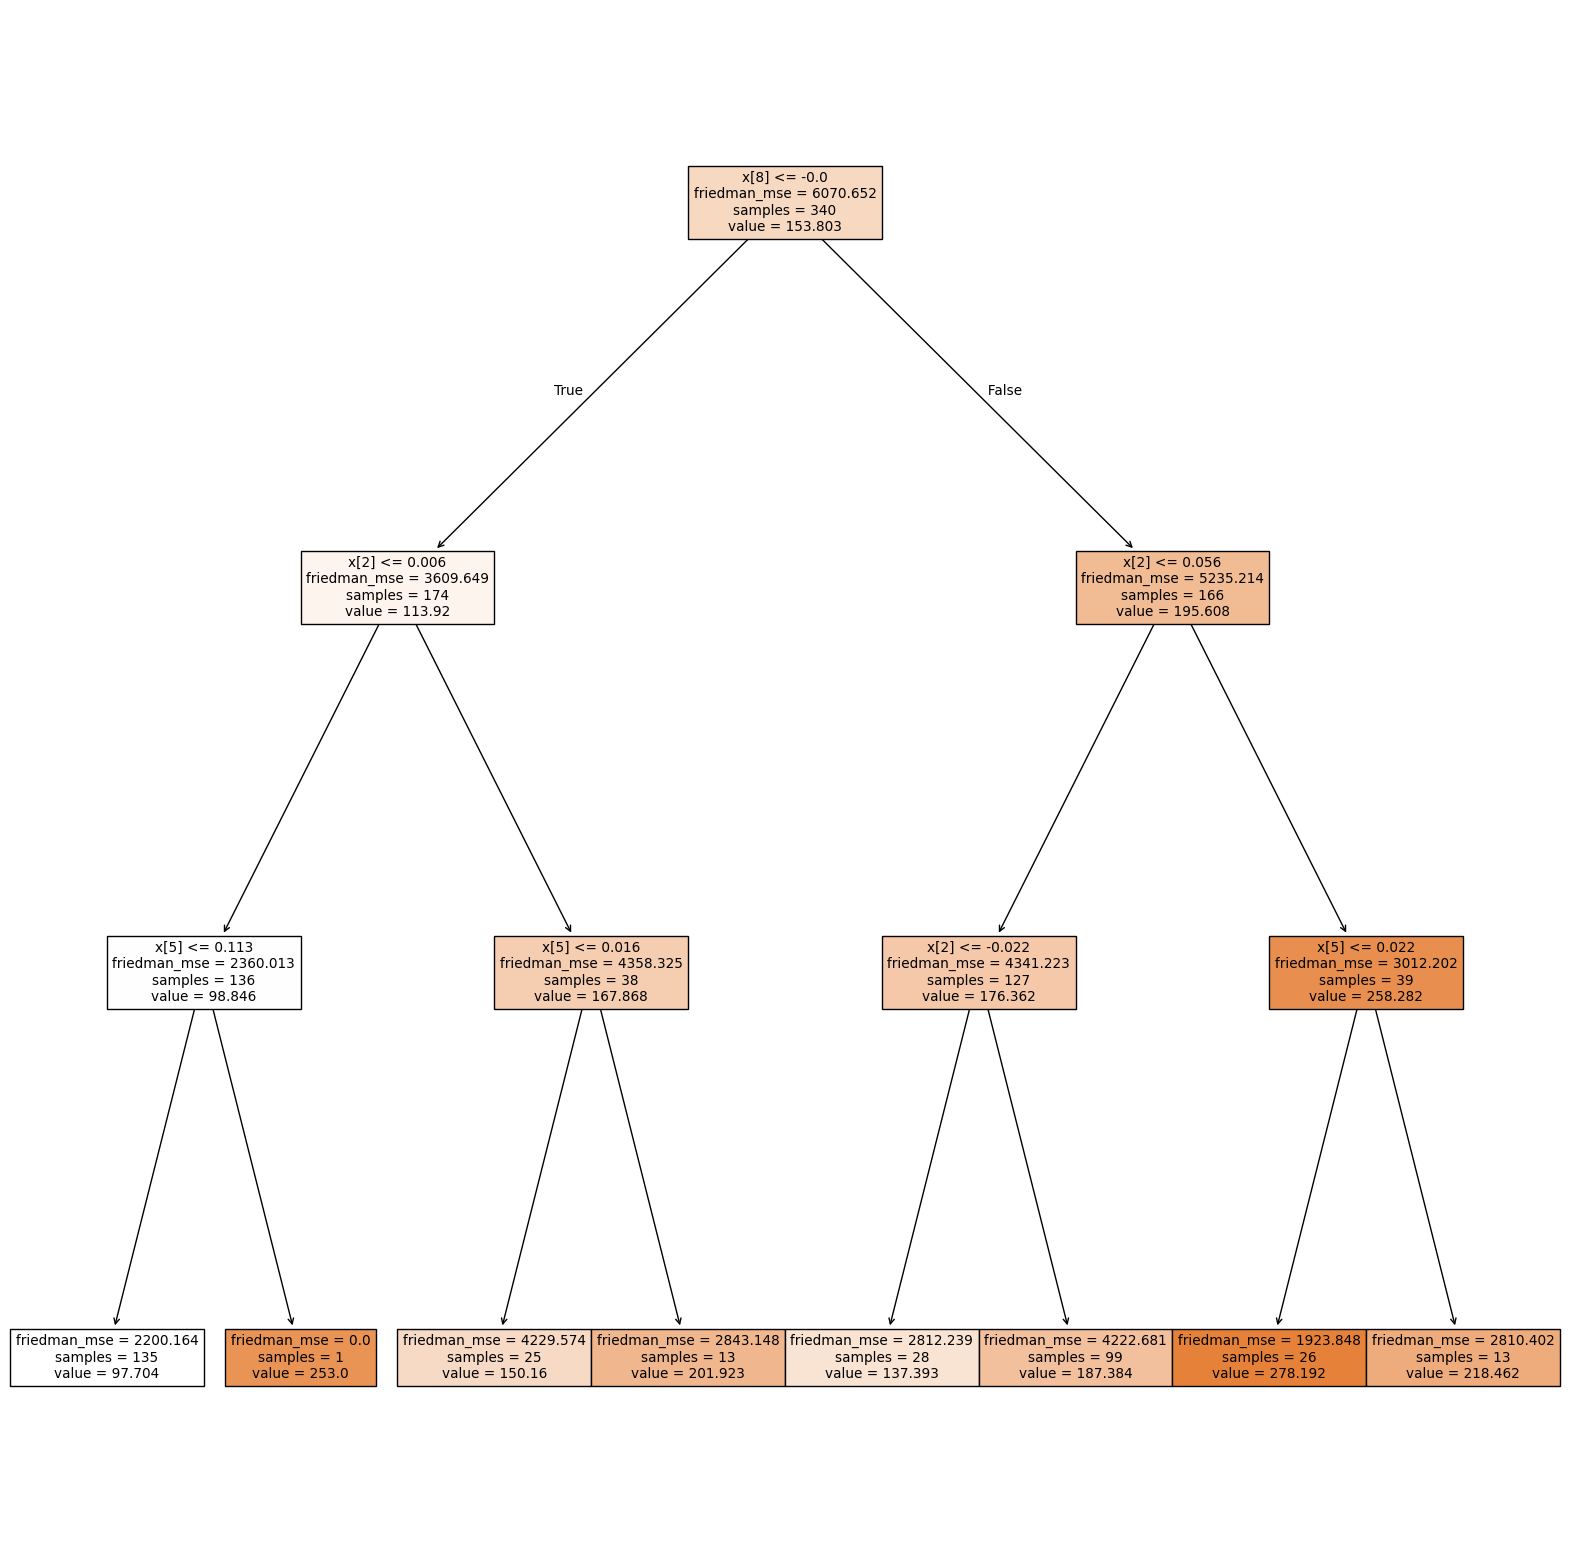

In [54]:
from sklearn import tree
plt.figure(figsize=(20,20))
tree.plot_tree(model,filled=True)